# Projeto 1 · Parte 2 — O experimento completo

Este notebook treina o detector, escolhe o modelo, define o ponto de operação da missão e mede
o desempenho final. É a parte que exige GPU.

**Antes de começar, execute o notebook `01_preparacao_dados.ipynb`.** Ele baixa o POP, verifica
a integridade dos arquivos e produz o `catalogo.csv` que carregaremos aqui.

| Etapa | Tempo aproximado |
|---|---|
| Treinamento (máximo de 100 épocas, `patience=10`) | projeção de ~50–55 min em uma RTX 4090 se a curva anterior se repetir; até ~2h30 |
| Avaliação e análise | ~15 min |

A duração reduzida é uma projeção baseada na execução anterior de 100 épocas, não uma
medição desta nova configuração. Reserve até cerca de 3 horas se a validação continuar melhorando.

Estime o custo multiplicando o tempo pelo preço atual da GPU e somando o armazenamento.
Veja o [guia de configuração](SETUP-RUNPOD-PROMPT.md).

A ordem das seções não é arbitrária. Treinamos, escolhemos o modelo na validação, congelamos a
decisão e só então tocamos no conjunto de teste. Parte do que este notebook ensina é *por que*
essa ordem não pode ser invertida — e o que acontece com a validade dos seus resultados quando
ela é.

## Requisitos de hardware

- GPU com **pelo menos 16 GB de VRAM** (esta configuração usa ~14,3 GB).
- Se a sua GPU tiver menos memória, reduza `BATCH` para 8 — mas anote que fez isso, porque deixa
  de ser a configuração do artigo que estamos reproduzindo.

## 0. Retomando o estado da preparação

Esta célula reconstrói o que o notebook 01 deixou pronto: os parâmetros do experimento, os
caminhos, o catálogo de imagens e as funções auxiliares de leitura de rótulos.

Os parâmetros estão repetidos aqui, e não importados de outro arquivo, de propósito: você deve
conseguir ler um notebook de experimento e saber, sem sair dele, com que configuração os
resultados foram produzidos.

In [1]:
# ===== Parâmetros do experimento (idênticos aos do notebook 01) =====

# Valores de referência reportados por Song et al. (2025)
EPOCAS = 100              # limite máximo; a versão didática pode encerrar antes
BATCH = 16
LR0 = 1e-3
OTIMIZADOR = "SGD"
IMGSZ = 1280
CONF_PAPER = 0.50          # limiar de confiança usado pelos autores ao reportar as métricas

# Decisões desta reprodução (não reportadas no artigo)
MODELO_BASE = "yolov8s.pt"
SEMENTE = 0
PACIENCIA = 10            # adaptação didática: épocas sem melhora na validação

# Requisito da missão de busca e salvamento — definido por nós, não pelo artigo
IOU_MATCH = 0.50
RECALL_ALVO = 0.90
FPPI_MAX = 1.0

NOME_EXECUCAO = f"yolov8s-pop-seed{SEMENTE}-es{PACIENCIA}"
# Use um nome novo ao mudar qualquer configuração; nunca apague o experimento anterior.
IOU_NMS = 0.7
MAX_DET = 300
CONF_MIN = 0.001
POLITICA_CHECKPOINT = "maior mAP50-95 na validação entre best.pt e last.pt; empate favorece best.pt"

# ===== Ambiente =====
import hashlib, json, math, os, platform, random, shutil, tempfile, warnings
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision

os.environ.setdefault("YOLO_CONFIG_DIR", str(Path(tempfile.gettempdir()) / "Ultralytics"))
import ultralytics
from ultralytics import YOLO

plt.rcParams["font.family"] = "DejaVu Sans"

# Mesma verificação do notebook 01: a hora de GPU já está correndo, então falhe agora.
assert ultralytics.__version__ == "8.2.0", (
    f"ultralytics {ultralytics.__version__} instalada; este projeto exige a 8.2.0 (veja o README)"
)
assert torch.__version__.split("+")[0] == "2.5.1", (
    f"torch {torch.__version__} instalado; use torch 2.5.1 e reinicie o kernel (veja o README)."
)
assert torchvision.__version__.split("+")[0] == "0.20.1", "Use torchvision 0.20.1."
assert np.__version__ == "1.26.4", "Use numpy 1.26.4 e reinicie o kernel."

# A ultralytics 8.2.0 chama torch.load() sem weights_only=False, e o PyTorch avisa sobre isso
# a cada checkpoint carregado. O aviso é esperado e não indica problema aqui: os únicos
# checkpoints carregados são o yolov8s.pt oficial e os que você mesmo treinou. Silenciamos
# para não poluir a saída — mas nunca silencie um aviso que você não saiba explicar.
warnings.filterwarnings("ignore", message=".*weights_only.*")
DEVICE = 0 if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    raise RuntimeError("Nenhuma GPU detectada. Este notebook exige GPU — veja o README.")

# A versão do PyTorch que este projeto exige (série 2.5) traz código compilado apenas até a
# arquitetura sm_90. Placas mais novas — Blackwell, como a RTX 5090 — são sm_120 e falhariam
# no meio do treinamento com a mensagem críptica "no kernel image is available for execution
# on the device". Melhor descobrir agora, em um segundo, do que depois de duas horas.
_maior_suportada = max(int(a[3:]) for a in torch.cuda.get_arch_list() if a.startswith("sm_"))
_capacidade = torch.cuda.get_device_capability(0)
_desta_gpu = _capacidade[0] * 10 + _capacidade[1]
if _desta_gpu > _maior_suportada:
    raise RuntimeError(
        f"A GPU {torch.cuda.get_device_name(0)} é sm_{_desta_gpu}, mas o torch "
        f"{torch.__version__} só tem código até sm_{_maior_suportada}.\n"
        "Use uma placa de geração compatível (RTX 4090, RTX 3090, A100, A6000, L40S). "
        "Veja a seção de requisitos no README."
    )

if os.environ.get("POP_RAIZ"):
    RAIZ = Path(os.environ["POP_RAIZ"]).expanduser().resolve()
elif Path("/workspace").exists():
    RAIZ = Path("/workspace/projeto-pop")
elif Path("/content").exists():
    RAIZ = Path("/content/projeto-pop")
else:
    RAIZ = Path.cwd() / "projeto-pop"

DADOS = RAIZ / "data"
POP_YOLO = DADOS / "pop_yolo"
YAML = POP_YOLO / "pop.yaml"
EXEC = RAIZ / "runs" / NOME_EXECUCAO
EXEC.mkdir(parents=True, exist_ok=True)

if str(RAIZ).startswith("/workspace") and not os.path.ismount("/workspace"):
    print("AVISO: /workspace não parece ser um volume persistente montado.")
    print("       Confirme no painel o tipo de armazenamento antes de encerrar a máquina.")
    print("       Se você alugou um servidor, verifique se o volume foi anexado em /workspace.")
LARGURA, ALTURA = 1280, 1024

if not (RAIZ / "catalogo.csv").exists():
    raise FileNotFoundError(
        f"Não encontrei {RAIZ / 'catalogo.csv'}. Execute 01_preparacao_dados.ipynb antes deste notebook."
    )
catalogo = pd.read_csv(RAIZ / "catalogo.csv")
catalogo["caminho"] = catalogo["caminho"].map(lambda p: str(RAIZ / p))
if not YAML.is_file() or not all(Path(p).is_file() for p in catalogo["caminho"]):
    raise FileNotFoundError("Dados ausentes ou movidos. Execute o notebook 01 nesta máquina.")
for split in ("train", "val", "test"):
    if not (catalogo.split == split).any():
        raise ValueError(f"Catálogo sem o split {split}; refaça o notebook 01.")

random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)
torch.cuda.manual_seed_all(SEMENTE)


def agora():
    return datetime.now(timezone.utc).isoformat()


def sha256(caminho, bloco=8 * 1024 * 1024):
    h = hashlib.sha256()
    with open(caminho, "rb") as f:
        for parte in iter(lambda: f.read(bloco), b""):
            h.update(parte)
    return h.hexdigest()


def ler_rotulos_yolo(caminho_txt, largura, altura):
    """Lê caixas YOLO sem tratar um rótulo ausente ou inválido como imagem vazia."""
    caixas = []
    for numero, linha in enumerate(Path(caminho_txt).read_text(encoding="utf-8").splitlines(), 1):
        if not linha.strip():
            continue
        partes = linha.split()
        if len(partes) != 5:
            raise ValueError(f"Rótulo inválido em {caminho_txt}, linha {numero}")
        classe, xc, yc, w, h = map(float, partes)
        if (not all(math.isfinite(v) for v in (classe, xc, yc, w, h))
                or classe != 0 or w <= 0 or h <= 0
                or xc - w/2 < -1e-7 or yc - h/2 < -1e-7
                or xc + w/2 > 1 + 1e-7 or yc + h/2 > 1 + 1e-7):
            raise ValueError(f"Caixa inválida em {caminho_txt}, linha {numero}")
        caixas.append([(xc - w/2) * largura, (yc - h/2) * altura,
                       (xc + w/2) * largura, (yc + h/2) * altura])
    return np.asarray(caixas, dtype=np.float64).reshape(-1, 4)


def cena_indice_altitude(stem):
    partes = stem.split("_")
    try:
        altitude = float(partes[2])
    except (IndexError, ValueError):
        altitude = float("nan")
    return partes[0], int(partes[1]), altitude


def faixa_altitude(altitude):
    return min((30, 50, 70), key=lambda a: abs(a - altitude)) if altitude == altitude else None


print("Ambiente pronto.")
print(f"  GPU        : {torch.cuda.get_device_name(0)}")
print(f"  torch      : {torch.__version__} (CUDA {torch.version.cuda})")
print(f"  ultralytics: {ultralytics.__version__}")
print(f"  catálogo   : {len(catalogo)} imagens, {int(catalogo.pessoas.sum())} pessoas")
print(f"  execução   : {EXEC}")

Ambiente pronto.
  GPU        : NVIDIA GeForce RTX 4090
  torch      : 2.5.1+cu121 (CUDA 12.1)
  ultralytics: 8.2.0
  catálogo   : 8768 imagens, 26811 pessoas
  execução   : /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10


## 1. O que a biblioteca faz sem você pedir

Ao chamar `model.train()`, dezenas de decisões são tomadas por você: quais transformações
aplicar às imagens, com que probabilidade, como combinar os termos da função de perda, como
agendar a taxa de aprendizado.

Essas decisões afetam o resultado tanto quanto os hiperparâmetros que você escolheu — e não
aparecem em nenhum lugar do seu código. Quem lê seu relatório não tem como saber que houve
mosaico com probabilidade 1,0, ou espelhamento horizontal em metade das imagens.

A célula abaixo torna esses defaults visíveis. É um hábito barato que evita uma classe inteira
de confusão ao comparar experimentos.

Repare que **dois dos valores desta tabela coincidem com o que o artigo reporta** (Tabela 5):
mosaico ativo e espelhamento aleatório. Um terceiro item reportado pelos autores, o valor de
preenchimento 114, não aparece aqui porque não é um parâmetro configurável — é uma constante
interna da Ultralytics, embutida no redimensionamento com bordas. Ou seja, boa parte do que os
autores descrevem como escolha de projeto é, na prática, o comportamento padrão da ferramenta. Isso não
diminui o trabalho deles — mas é exatamente o tipo de coincidência que você só percebe quando
inspeciona os defaults em vez de assumi-los.

Dois valores merecem atenção:

- **`mosaic: 1.0`** — toda imagem de treino é, na verdade, uma composição de quatro imagens.
  Isso ajuda o modelo a lidar com objetos em posições e escalas variadas, e é provavelmente
  benéfico aqui, já que aumenta a variedade de contextos em que uma pessoa pequena aparece.
- **`fliplr: 0.5`** — metade das imagens é espelhada horizontalmente. Faz sentido para vistas
  aéreas, onde não existe "lado certo". Note que `flipud` (vertical) é 0,0 por padrão, o que
  é um default da biblioteca; em vistas aéreas, a plausibilidade dessa transformação depende
  da geometria de captura e deve ser avaliada em outro experimento.

In [2]:
from ultralytics.utils import DEFAULT_CFG_DICT

chaves = ["rect", "close_mosaic", "hsv_h", "hsv_s", "hsv_v", "degrees", "translate",
          "scale", "shear", "perspective", "flipud", "fliplr", "mosaic", "mixup", "copy_paste"]
defaults = {k: DEFAULT_CFG_DICT.get(k) for k in chaves}
display(pd.DataFrame.from_dict(defaults, orient="index", columns=["padrão da Ultralytics 8.2.0"]))

,padrão da Ultralytics 8.2.0
rect,False
close_mosaic,10
hsv_h,0.015
hsv_s,0.7
hsv_v,0.4
degrees,0.0
translate,0.1
scale,0.5
shear,0.0
perspective,0.0


## 2. A configuração do treinamento

Aqui montamos os argumentos e — o ponto importante desta seção — **gravamos em disco a
especificação completa antes de treinar**, separando o que veio do artigo do que veio dos
defaults da biblioteca.

Registrar a configuração antes desta execução permite identificar as decisões que a
produziram e impedir alterações silenciosas. A parada antecipada foi escolhida a partir da
validação de uma execução anterior; essa origem é explicitada abaixo. O teste deve permanecer
reservado para a avaliação final, sem orientar ajustes de configuração.

Repare na estrutura do `especificacao.json`: `reportado_no_artigo` e
`defaults_nao_reportados`. Essa separação é honesta com o leitor — deixa explícito que boa
parte do que determina o resultado não estava no artigo original e foi herdada da ferramenta.

### Adaptação didática: parada antecipada

O artigo de Song et al. reporta treinamento por **100 épocas**. Antes de disponibilizar esta
atividade, realizamos uma execução de referência com as **100 épocas completas**. Para fins
didáticos, adotamos aqui **no máximo 100 épocas e `patience=10`**, reduzindo o tempo e o custo
quando a validação deixa de apresentar melhora.

Na Ultralytics 8.2.0, a parada acompanha o critério `fitness` na validação, calculado como
`0,1 × mAP50 + 0,9 × mAP50–95`. Após 10 épocas consecutivas sem melhora nesse critério, o treino
é encerrado. A seleção posterior entre `best.pt` e `last.pt` continua usando o maior mAP50–95
na validação. O conjunto de teste não participa dessas decisões.

Mantemos o limite de 100 para preservar o planejamento da taxa de aprendizado; definir
apenas 35 épocas também mudaria esse planejamento. A regra foi escolhida com base na
validação da execução de referência e deve ser registrada como adaptação metodológica,
não como reprodução integral do protocolo do artigo. Uma nova execução pode parar em outra
época e produzir resultados diferentes.

Para executar novamente as 100 épocas completas, defina `PACIENCIA=0` nos dois notebooks
(desativa a parada antecipada na Ultralytics) e utilize um novo nome de execução. Preserve
os arquivos anteriores. A política adotada e as épocas efetivas ficam registradas nos resultados.


In [3]:
cfg_treino = dict(
    data=str(YAML),
    epochs=EPOCAS,
    batch=BATCH,
    imgsz=IMGSZ,
    optimizer=OTIMIZADOR,
    lr0=LR0,
    rect=False,
    seed=SEMENTE,
    deterministic=True,
    patience=PACIENCIA,  # adaptação didática; 0 desativa a parada antecipada
    save=True,
    save_period=10,
    val=True,
    plots=True,
    device=DEVICE,
    project=str(EXEC.parent),
    name=NOME_EXECUCAO,
    exist_ok=True,
)

chaves_defaults = ["lrf", "momentum", "weight_decay", "warmup_epochs", "box", "cls", "dfl",
                   "nbs", "cos_lr", "close_mosaic", "amp", "translate", "scale", "fliplr", "mosaic"]

especificacao = {
    "modelo_base": MODELO_BASE,
    "cfg_treino": cfg_treino,
    "ambiente": {"torch": torch.__version__, "torchvision": torchvision.__version__,
                 "numpy": np.__version__, "ultralytics": ultralytics.__version__},
    "avaliacao": {"iou_nms": IOU_NMS, "max_det": MAX_DET, "conf_min": CONF_MIN},
    "reportado_no_artigo": {
        "epochs": 100, "batch": BATCH, "lr0": LR0, "optimizer": OTIMIZADOR,
        "resolucao_origem": [LARGURA, ALTURA], "confianca_de_teste": CONF_PAPER,
    },
    "decisoes_desta_reproducao": {
        "ultralytics": ultralytics.__version__, "imgsz": IMGSZ,
        "seed": SEMENTE, "politica_de_checkpoint": POLITICA_CHECKPOINT,
        "epocas_maximas": EPOCAS, "patience": PACIENCIA,
        "criterio_parada": "fitness na validação: 0.1 * mAP50 + 0.9 * mAP50-95",
        "finalidade_parada": "reduzir tempo e custo da execução didática",
    },
    "defaults_nao_reportados": {k: DEFAULT_CFG_DICT.get(k) for k in chaves_defaults},
    "requisito_da_missao": {
        "iou_match": IOU_MATCH, "recall_alvo": RECALL_ALVO, "fppi_max": FPPI_MAX,
    },
}
def gravar_registro_unico(caminho, registro, ignorar=()):
    """Reexecuções idênticas preservam o registro; mudanças exigem outro experimento."""
    caminho = Path(caminho)
    if caminho.exists():
        anterior = json.loads(caminho.read_text(encoding="utf-8"))
        comparar = lambda d: {k: v for k, v in d.items() if k not in ignorar}
        if comparar(anterior) != comparar(registro):
            raise RuntimeError(f"{caminho.name} já existe com outra configuração. "
                               "Escolha outro NOME_EXECUCAO e reexecute desde o início.")
        return anterior
    with caminho.open("x", encoding="utf-8") as f:
        json.dump(registro, f, indent=2, ensure_ascii=False)
    return registro


ARQ_ESPECIFICACAO = EXEC / "especificacao.json"
if not ARQ_ESPECIFICACAO.exists() and any((EXEC / "weights").glob("*.pt")):
    raise RuntimeError("Há pesos sem especificação verificável. Use outro NOME_EXECUCAO.")
especificacao = gravar_registro_unico(ARQ_ESPECIFICACAO, especificacao)
ambiente_treino = {
    "registrado_em": agora(), "python": platform.python_version(),
    **especificacao["ambiente"], "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0), "semente": SEMENTE,
}
gravar_registro_unico(EXEC / "ambiente_treino.json", ambiente_treino, ignorar=("registrado_em",))
print(json.dumps(especificacao, indent=2, ensure_ascii=False))

{
  "modelo_base": "yolov8s.pt",
  "cfg_treino": {
    "data": "/workspace/projeto-pop-es10-20260919/data/pop_yolo/pop.yaml",
    "epochs": 100,
    "batch": 16,
    "imgsz": 1280,
    "optimizer": "SGD",
    "lr0": 0.001,
    "rect": false,
    "seed": 0,
    "deterministic": true,
    "patience": 10,
    "save": true,
    "save_period": 10,
    "val": true,
    "plots": true,
    "device": 0,
    "project": "/workspace/projeto-pop-es10-20260919/runs",
    "name": "yolov8s-pop-seed0-es10",
    "exist_ok": true
  },
  "ambiente": {
    "torch": "2.5.1+cu121",
    "torchvision": "0.20.1+cu121",
    "numpy": "1.26.4",
    "ultralytics": "8.2.0"
  },
  "avaliacao": {
    "iou_nms": 0.7,
    "max_det": 300,
    "conf_min": 0.001
  },
  "reportado_no_artigo": {
    "epochs": 100,
    "batch": 16,
    "lr0": 0.001,
    "optimizer": "SGD",
    "resolucao_origem": [
      1280,
      1024
    ],
    "confianca_de_teste": 0.5
  },
  "decisoes_desta_reproducao": {
    "ultralytics": "8.2.0",
   

## 3. Treinamento

Esta célula pode terminar antes das 100 épocas. A projeção é de **50–55 minutos em uma
RTX 4090** se a curva anterior se repetir; o treinamento completo levou cerca de **2h30**.
O encerramento depende da validação, não de um tempo ou de uma época previamente fixados.

O que observar enquanto roda:

- **`box_loss`, `cls_loss`, `dfl_loss`** devem cair. `box_loss` mede o erro de localização,
  `cls_loss` o de classificação (trivial aqui, há uma só classe) e `dfl_loss` a qualidade da
  distribuição usada para refinar as bordas da caixa.
- **A memória de GPU** aparece na segunda coluna. Se você receber um erro de falta de memória,
  reduza `BATCH` para 8 — use outro `NOME_EXECUCAO` e reexecute desde o início. Isso passa a ser outro experimento.
- **O mosaico tem desligamento programado para as 10 últimas épocas do limite de 100**
  (`close_mosaic: 10`). Se a parada antecipada ocorrer antes dessa fase, ela não será executada.
  Essa é outra diferença em relação ao treinamento completo.

Como configuramos `save_period=10`, a Ultralytics grava um checkpoint a cada dez épocas, além
de `best.pt` (o de melhor desempenho na validação) e `last.pt` (o da última época). Os intermediários ficam disponíveis caso você queira inspecionar o
treinamento depois; na seção 5 vamos escolher entre `best.pt` e `last.pt`, e a escolha tem
consequências.

Ao retornar normalmente do treinamento, a célula grava `treinamento_concluido.json` com a
quantidade efetiva de épocas e os hashes dos resultados e pesos. Esse registro permite
reabrir o notebook e reutilizar um treino encerrado por parada antecipada. Uma interrupção
antes do retorno não gera esse registro e continua sujeita à retomada de `last.pt`.


In [4]:
PESOS = EXEC / "weights"
RESULTADOS = EXEC / "results.csv"
ARQ_CONCLUSAO = EXEC / "treinamento_concluido.json"


def treino_ja_concluido():
    """Reconhece conclusão normal, inclusive antes do limite por parada antecipada."""
    if not (PESOS / "best.pt").exists() or not RESULTADOS.exists():
        return False
    if not ARQ_CONCLUSAO.exists():
        return False  # Um CSV parcial não comprova que train() terminou normalmente.
    registro = json.loads(ARQ_CONCLUSAO.read_text(encoding="utf-8"))
    atuais = {
        "especificacao_sha256": sha256(ARQ_ESPECIFICACAO),
        "resultados_sha256": sha256(RESULTADOS),
        "best_sha256": sha256(PESOS / "best.pt"),
        "last_sha256": sha256(PESOS / "last.pt"),
    }
    if any(registro.get(k) != v for k, v in atuais.items()):
        raise RuntimeError("Os arquivos mudaram após a conclusão. Use outro NOME_EXECUCAO.")
    return True


def registrar_conclusao_treino():
    """Chamar somente após train() retornar normalmente, nunca em finally."""
    historico = pd.read_csv(RESULTADOS)
    historico.columns = historico.columns.str.strip()
    epocas = len(historico)
    if not 0 < epocas <= EPOCAS:
        raise RuntimeError("Histórico de épocas incompatível com a configuração.")
    registro = {
        "concluido_em": agora(),
        "epocas_maximas": EPOCAS,
        "epocas_executadas": epocas,
        "patience": PACIENCIA,
        "motivo": "limite_de_epocas" if epocas == EPOCAS else "parada_antecipada",
        "especificacao_sha256": sha256(ARQ_ESPECIFICACAO),
        "resultados_sha256": sha256(RESULTADOS),
        "best_sha256": sha256(PESOS / "best.pt"),
        "last_sha256": sha256(PESOS / "last.pt"),
    }
    gravar_registro_unico(ARQ_CONCLUSAO, registro, ignorar=("concluido_em",))


gravar_registro_unico(ARQ_ESPECIFICACAO, especificacao)
if cfg_treino != especificacao["cfg_treino"]:
    raise RuntimeError("A configuração mudou. Reexecute desde o início com outro NOME_EXECUCAO.")
if treino_ja_concluido():
    _conclusao = json.loads(ARQ_CONCLUSAO.read_text(encoding="utf-8"))
    print(f"Treinamento já concluído ({_conclusao['epocas_executadas']} épocas; "
          f"{_conclusao['motivo']}). Reaproveitando os pesos existentes.")
    print("Para treinar do zero, escolha outro NOME_EXECUCAO e reexecute desde o início.")
elif (PESOS / "last.pt").exists():
    # Ao retomar, a Ultralytics usa os argumentos gravados no checkpoint e ignora cfg_treino.
    # Quem reduziu BATCH depois de um "CUDA out of memory" precisa saber disso, senão o erro
    # se repete exatamente igual e a causa fica invisível.
    _args_salvos = torch.load(PESOS / "last.pt", map_location="cpu").get("train_args", {})
    _batch_salvo = _args_salvos.get("batch")
    if _batch_salvo is not None and _batch_salvo != BATCH:
        raise RuntimeError(
            f"O treinamento interrompido usou batch={_batch_salvo}, mas esta célula pede "
            f"batch={BATCH}.\nAo retomar, a Ultralytics ignora a configuração acima e reusa a "
            f"do checkpoint — sua mudança não teria efeito.\nUse outro NOME_EXECUCAO e treine do zero."
        )
    print("Encontrei um treinamento interrompido. Retomando a partir de last.pt...")
    YOLO(str(PESOS / "last.pt")).train(resume=True)
    registrar_conclusao_treino()
else:
    YOLO(MODELO_BASE).train(**cfg_treino)
    registrar_conclusao_treino()

print("\nCheckpoints disponíveis:", sorted(p.name for p in PESOS.glob("*.pt")))

New https://pypi.org/project/ultralytics/8.4.155 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/workspace/projeto-pop-es10-20260919/data/pop_yolo/pop.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=1280, save=True, save_period=10, cache=False, device=0, workers=8, project=/workspace/projeto-pop-es10-20260919/runs, name=yolov8s-pop-seed0-es10, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, aug

100%|██████████| 755k/755k [00:00<00:00, 5.40MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           


  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1838080  ultralytics.nn.modules.block.C2f             [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    591360  ultralytics.nn.modules.block.C2f             [768, 256, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None

100%|██████████| 6.23M/6.23M [00:00<00:00, 26.2MB/s]
/opt/pop-es10-env/lib/python3.12/site-packages/ultralytics/utils/checks.py:640: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):


...

     35/100      14.2G      0.878     0.4077     0.9074         58       1280: 100%|██████████| 347/347 [01:14<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 73/73 [00:12<00:00,  6.01it/s]

                   all       2320       6546      0.906      0.789      0.868      0.642
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 25, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



35 epochs completed in 0.869 hours.
Optimizer stripped from /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10/weights/last.pt, 22.6MB
Optimizer stripped from /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10/weights/best.pt, 22.6MB

Validating /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 73/73 [00:13<00:00,  5.34it/s]


                   all       2320       6546      0.914      0.796      0.877      0.652
Speed: 0.3ms preprocess, 2.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10

Checkpoints disponíveis: ['best.pt', 'epoch10.pt', 'epoch20.pt', 'epoch30.pt', 'last.pt']


## 4. A dinâmica do treinamento

As curvas contam uma história que o número final esconde. Observe:

1. **Em que época o mAP parou de melhorar?** Se isso aconteceu muito antes do fim, o orçamento
   de épocas foi maior que o necessário — informação útil para planejar o próximo experimento.
2. **A perda de validação acompanha a de treino?** Se a de treino cai e a de validação sobe,
   o modelo está memorizando o conjunto de treino.
3. **A taxa de aprendizado** decai linearmente até `lr0 × lrf`. A queda abrupta nas primeiras
   épocas é o *warmup*: a Ultralytics parte de uma taxa alta para o grupo de parâmetros de bias
   e a traz até `lr0` ao longo de três épocas. O desligamento do mosaico, na época 90, **não**
   altera a taxa de aprendizado — ele aparece como uma inflexão nas curvas de perda, no painel
   do meio.

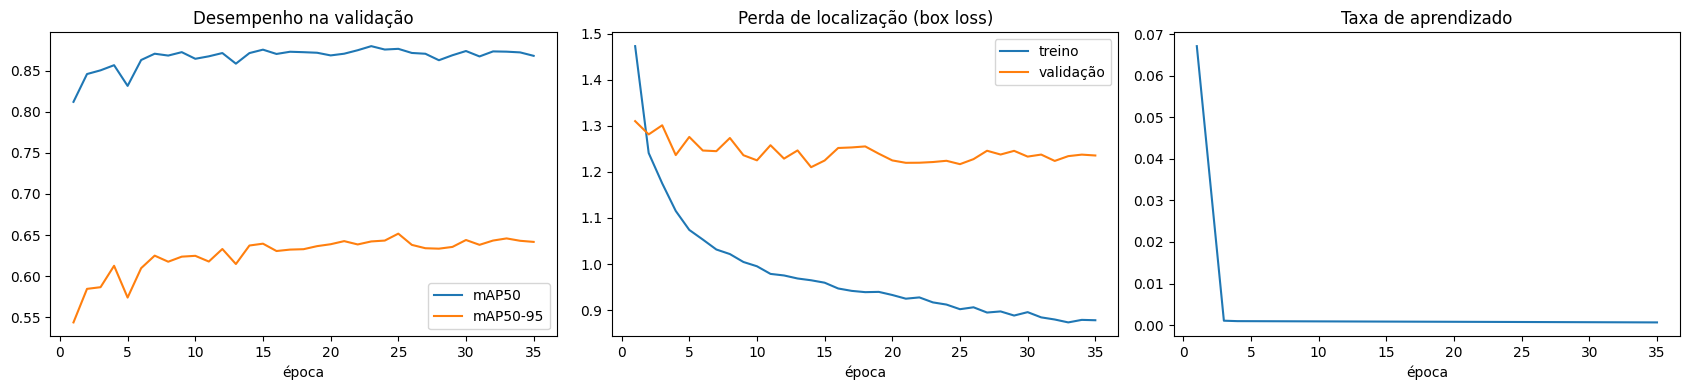

{
  "melhor_epoca_map50": 23,
  "melhor_epoca_map50_95": 25,
  "map50_na_ultima_epoca": 0.86832,
  "map50_95_na_ultima_epoca": 0.64162
}


In [5]:
arquivo_resultados = EXEC / "results.csv"
hist = pd.read_csv(arquivo_resultados)
hist.columns = hist.columns.str.strip()   # a Ultralytics 8.2.0 grava os nomes com espaços

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(hist.epoch, hist["metrics/mAP50(B)"], label="mAP50")
ax[0].plot(hist.epoch, hist["metrics/mAP50-95(B)"], label="mAP50-95")
ax[0].set_title("Desempenho na validação")
ax[0].legend()

ax[1].plot(hist.epoch, hist["train/box_loss"], label="treino")
ax[1].plot(hist.epoch, hist["val/box_loss"], label="validação")
ax[1].set_title("Perda de localização (box loss)")
ax[1].legend()

ax[2].plot(hist.epoch, hist["lr/pg0"])
ax[2].set_title("Taxa de aprendizado")

for a in ax:
    a.set_xlabel("época")
plt.tight_layout()
plt.show()

print(json.dumps({
    "melhor_epoca_map50": int(hist.loc[hist["metrics/mAP50(B)"].idxmax(), "epoch"]),
    "melhor_epoca_map50_95": int(hist.loc[hist["metrics/mAP50-95(B)"].idxmax(), "epoch"]),
    "map50_na_ultima_epoca": float(hist.iloc[-1]["metrics/mAP50(B)"]),
    "map50_95_na_ultima_epoca": float(hist.iloc[-1]["metrics/mAP50-95(B)"]),
}, indent=2))

## 5. Camada A — escolher o modelo pela métrica técnica

Temos dois candidatos, `best.pt` e `last.pt`, e precisamos escolher um. A regra que adotamos:
**escolher pelo maior mAP50-95 na validação**, nunca no teste.

A célula abaixo aplica essa regra em vez de apenas enunciá-la. Na prática ela tende a confirmar
o que a própria Ultralytics já fez: o `best.pt` é o checkpoint de melhor *fitness* na validação,
uma média ponderada (0,1 × mAP50 + 0,9 × mAP50-95) — próxima, mas não idêntica, ao nosso
critério. Quando os dois discordam, quem decide é a nossa regra, escrita antes de olhar o
resultado.

Isso merece ser dito de forma direta, porque é o erro metodológico mais comum e mais difícil de
detectar depois. Se você escolhesse o checkpoint olhando o desempenho no teste, o número que
reportasse no teste deixaria de ser uma estimativa honesta: você teria usado o teste para tomar
uma decisão, e ele não mede mais desempenho em dados não vistos — mede o quanto você o explorou.

O `mAP50` mede a qualidade das detecções com sobreposição mínima de 50%. O `mAP50-95` faz a média
sobre limiares de 50% a 95% e pune localização imprecisa — para objetos pequenos, é bem mais
severo, e você verá isso nos números.

In [6]:
def metricas_ultralytics(pesos, split, conf=None):
    '''Roda a validação oficial da Ultralytics e devolve as métricas técnicas.'''
    kwargs = dict(data=str(YAML), split=split, imgsz=IMGSZ, batch=BATCH,
                  device=DEVICE, plots=False, verbose=False, iou=IOU_NMS, max_det=MAX_DET,
                  project=str(EXEC / "avaliacoes"), name=f"{split}-{Path(pesos).stem}-{conf}", exist_ok=True)
    if conf is not None:
        kwargs["conf"] = conf
    m = YOLO(str(pesos)).val(**kwargs)
    ms = float(dict(getattr(m, "speed", {}) or {}).get("inference", float("nan")))
    return {
        "mAP50": float(m.box.map50),
        "mAP50-95": float(m.box.map),
        "precisao": float(np.mean(m.box.p)),
        "recall": float(np.mean(m.box.r)),
        "ms_por_imagem": ms,
        "fps": 1000.0 / ms if ms > 0 else float("nan"),
    }


candidatos = {nome: PESOS / f"{nome}.pt" for nome in ("best", "last") if (PESOS / f"{nome}.pt").is_file()}
if not candidatos:
    raise FileNotFoundError("Nenhum checkpoint encontrado; conclua a seção de treinamento.")
tabela = pd.DataFrame({nome: metricas_ultralytics(p, "val", conf=CONF_MIN) for nome, p in candidatos.items()}).T
display(tabela.round(4))

# A regra é aplicada, não apenas anunciada: quem decide é a tabela acima.
escolhido = tabela["mAP50-95"].idxmax()
CHECKPOINT = candidatos[escolhido]
print(f"Checkpoint escolhido: {escolhido}.pt (maior mAP50-95 na validação)")
print("Caminho:", CHECKPOINT)

Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/val.cache... 2320 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2320/2320 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 145/145 [00:16<00:00,  8.92it/s]

                   all       2320       6546      0.912      0.795      0.877      0.651
Speed: 0.3ms preprocess, 4.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)


Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/val.cache... 2320 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2320/2320 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 145/145 [00:15<00:00,  9.12it/s]

                   all       2320       6546      0.908      0.787      0.868      0.642
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 0.6ms postprocess per image


,mAP50,mAP50-95,precisao,recall,ms_por_imagem,fps
best,0.8768,0.6512,0.9121,0.7954,4.1584,240.4788
last,0.8684,0.6416,0.9075,0.7869,3.9968,250.1989


Checkpoint escolhido: best.pt (maior mAP50-95 na validação)
Caminho: /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10/weights/best.pt


### 5.1 O limiar de confiança muda o que a métrica significa

Song et al. informam ter usado confiança de 0,50. A prática padrão para calcular AP, porém, é
usar um limiar próximo de zero (0,001), porque o AP é uma integral sobre toda a curva
precisão-recall e descartar detecções de baixa confiança trunca essa curva.

Medimos das duas formas. A diferença entre elas não é erro de ninguém — é uma ambiguidade do
relato original, e explicitá-la é mais útil do que escolher silenciosamente uma das opções.

Compare os dois resultados sem pressupor a direção da diferença. O corte remove detecções e
altera a curva disponível para o cálculo. Os detalhes de interpolação de AP da implementação
também influenciam a comparação; uma mudança isolada não demonstra melhora do detector.


In [7]:
val_paper = metricas_ultralytics(CHECKPOINT, "val", conf=CONF_PAPER)
val_padrao = metricas_ultralytics(CHECKPOINT, "val", conf=0.001)

display(pd.DataFrame({
    f"validação · conf={CONF_PAPER} (como no artigo)": val_paper,
    "validação · conf=0.001 (padrão para AP)": val_padrao,
}).T.round(4))

Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/val.cache... 2320 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2320/2320 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 145/145 [00:15<00:00,  9.36it/s]

                   all       2320       6546      0.953       0.75      0.864      0.675
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 0.4ms postprocess per image


Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/val.cache... 2320 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2320/2320 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 145/145 [00:15<00:00,  9.17it/s]


                   all       2320       6546      0.912      0.795      0.877      0.651
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 0.5ms postprocess per image


,mAP50,mAP50-95,precisao,recall,ms_por_imagem,fps
validação · conf=0.5 (como no artigo),0.8645,0.6750,0.9532,0.7504,3.9956,250.2733
validação · conf=0.001 (padrão para AP),0.8768,0.6512,0.9121,0.7954,3.9935,250.4060


## 6. Camada B — o ponto de operação da missão

O mAP responde "quão bom é este detector?". A missão pergunta outra coisa: **"a que limiar de
confiança devo operar, para encontrar o máximo de pessoas sem afogar a equipe em alarmes falsos?"**

São perguntas diferentes e exigem métricas diferentes:

- **Recall** — a fração das pessoas que o detector encontrou. É o que importa quando o custo de
  não encontrar alguém é alto.
- **FPPI** (*false positives per image*) — quantos alarmes falsos, em média, por imagem. É o que
  determina se a equipe consegue usar o sistema ou vai ignorá-lo.

Baixar o limiar de confiança aumenta o recall e o FPPI simultaneamente. Não existe escolha que
melhore os dois: existe uma curva, e escolher um ponto nela é uma decisão operacional.

Nosso requisito: **recall ≥ 0,90 com FPPI ≤ 1,0**. Se nenhum limiar satisfizer os dois, o
procedimento não inventa uma solução — ele registra que o alvo não foi atingido e escolhe o
melhor ponto possível dentro da restrição de FPPI. **Um requisito que nunca falha não é um
requisito.**

E o ponto crítico: **o limiar é escolhido na validação**, antes de qualquer contato com o teste.
Escolhê-lo no teste seria o mesmo erro da seção 5, em outra roupa.

In [8]:
def iou_matriz(a, b):
    '''Sobreposição (IoU) entre dois conjuntos de caixas.'''
    a = np.asarray(a, dtype=np.float64).reshape(-1, 4)
    b = np.asarray(b, dtype=np.float64).reshape(-1, 4)
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0])
    y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2])
    y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    uniao = area_a[:, None] + area_b[None, :] - inter
    return np.where(uniao > 0, inter / np.maximum(uniao, 1e-12), 0.0)


def casar_imagem(pred_xyxy, pred_conf, gt_xyxy, iou_min):
    '''Casa detecções com pessoas reais, da mais confiante para a menos confiante.

    Cada pessoa real só pode ser casada uma vez: a segunda detecção sobre a mesma
    pessoa é um falso positivo, não um acerto duplicado.
    '''
    pred_conf = np.asarray(pred_conf, dtype=np.float64)
    pred_tp = np.zeros(len(pred_conf), dtype=bool)
    gt_conf = np.full(len(gt_xyxy), -1.0)   # confiança com que cada pessoa foi encontrada
    if len(pred_conf) == 0 or len(gt_xyxy) == 0:
        return pred_tp, gt_conf
    ordem = np.argsort(-pred_conf, kind="stable")
    ious = iou_matriz(np.asarray(pred_xyxy)[ordem], gt_xyxy)
    livre = np.ones(len(gt_xyxy), dtype=bool)
    for k, i in enumerate(ordem):
        candidatos = np.where(livre, ious[k], -1.0)
        j = int(np.argmax(candidatos))
        if candidatos[j] >= iou_min:
            livre[j] = False
            pred_tp[i] = True
            gt_conf[j] = pred_conf[i]
    return pred_tp, gt_conf


def avaliar(registros, iou_min):
    '''Constrói a curva recall x FPPI varrendo todos os limiares de confiança.'''
    casamentos = [casar_imagem(r["pred_xyxy"], r["pred_conf"], r["gt_xyxy"], iou_min) for r in registros]
    conf = np.concatenate([r["pred_conf"] for r in registros]) if registros else np.zeros(0)
    tp = np.concatenate([c[0] for c in casamentos]) if registros else np.zeros(0, dtype=bool)
    ordem = np.argsort(-conf, kind="stable")
    conf, tp = conf[ordem], tp[ordem]
    n_gt = int(sum(len(r["gt_xyxy"]) for r in registros))
    n_img = len(registros)
    ctp, cfp = np.cumsum(tp), np.cumsum(~tp)
    ultimo = np.r_[conf[1:] != conf[:-1], True] if len(conf) else np.zeros(0, dtype=bool)
    curva = pd.DataFrame({
        "limiar": conf[ultimo],
        "recall": ctp[ultimo] / max(n_gt, 1),
        "fppi": cfp[ultimo] / max(n_img, 1),
        "precisao": ctp[ultimo] / np.maximum(ctp[ultimo] + cfp[ultimo], 1),
    })
    return {"iou_min": iou_min, "n_gt": n_gt, "n_img": n_img, "curva": curva, "casamentos": casamentos}


def escolher_limiar(curva, recall_alvo, fppi_max):
    '''Maior confiança que satisfaz recall >= alvo E fppi <= teto.

    Se nenhum limiar satisfizer os dois, devolve o melhor recall possível dentro do
    teto de FPPI e marca atingiu_alvo=False. O requisito precisa poder falhar.
    '''
    if curva.empty:
        return {"limiar": float(np.nextafter(1.0, np.inf)), "recall": 0.0, "fppi": 0.0, "atingiu_alvo": False}
    ok = curva[(curva.recall >= recall_alvo) & (curva.fppi <= fppi_max)]
    if not ok.empty:
        return {"limiar": float(ok.iloc[0].limiar), "recall": float(ok.iloc[0].recall),
                "fppi": float(ok.iloc[0].fppi), "atingiu_alvo": True}
    possivel = curva[curva.fppi <= fppi_max]
    if possivel.empty:
        # Acima da maior confiança, nenhuma detecção passa; o teto de FPPI é respeitado.
        return {"limiar": float(np.nextafter(max(1.0, float(curva.limiar.max())), np.inf)),
                "recall": 0.0, "fppi": 0.0, "atingiu_alvo": False}
    r = possivel.sort_values(["recall", "limiar"], ascending=[False, False]).iloc[0]
    return {"limiar": float(r.limiar), "recall": float(r.recall),
            "fppi": float(r.fppi), "atingiu_alvo": False}


def metricas_no_limiar(registros, aval, limiar):
    tps, fps, gts = [], [], []
    for r, (_, gt_conf) in zip(registros, aval["casamentos"]):
        tp = int((gt_conf >= limiar).sum())
        n_pred = int((r["pred_conf"] >= limiar).sum())
        tps.append(tp); fps.append(n_pred - tp); gts.append(len(r["gt_xyxy"]))
    tp, fp, gt = map(np.asarray, (tps, fps, gts))
    return {
        "confianca": float(limiar),
        "recall": float(tp.sum() / max(gt.sum(), 1)),
        "precisao": float(tp.sum() / max(tp.sum() + fp.sum(), 1)),
        "fppi": float(fp.sum() / max(len(gt), 1)),
        "pessoas_nao_encontradas": int(gt.sum() - tp.sum()),
    }


def coletar_predicoes(pesos, caminhos, lote=BATCH):
    '''Roda o detector e guarda as detecções brutas de cada imagem.

    As imagens são processadas em lotes físicos através de um diretório temporário
    de links simbólicos. Isso evita dois problemas da Ultralytics 8.2.0 ao receber
    uma lista de caminhos: o aquecimento com lote do tamanho da lista inteira
    (que estoura a memória da GPU) e a renomeação dos arquivos de saída.
    '''
    modelo = YOLO(str(pesos))
    registros = []
    caminhos = [Path(p) for p in caminhos]
    for i in range(0, len(caminhos), lote):
        trecho = caminhos[i:i + lote]
        with tempfile.TemporaryDirectory(prefix="pop-pred-") as td:
            td = Path(td)
            for p in trecho:
                alvo = os.path.realpath(p)
                try:
                    os.symlink(alvo, td / p.name)
                except OSError:
                    # No Windows, criar link simbólico exige privilégio elevado.
                    try:
                        os.link(alvo, td / p.name)
                    except OSError:
                        shutil.copy2(alvo, td / p.name)
            resultados = modelo.predict(source=str(td), imgsz=IMGSZ, conf=CONF_MIN, iou=IOU_NMS,
                                        max_det=MAX_DET, batch=len(trecho), device=DEVICE, verbose=False)
        por_stem = {p.stem: p for p in trecho}
        for res in resultados:
            origem = por_stem[Path(res.path).stem]   # casa pelo nome, não pela ordem do lote
            h, w = res.orig_shape
            rotulo = POP_YOLO / "labels" / origem.parent.name / f"{origem.stem}.txt"
            cena, _, altitude = cena_indice_altitude(origem.stem)
            boxes = res.boxes
            registros.append({
                "caminho": str(origem), "stem": origem.stem,
                "cena": cena, "faixa": faixa_altitude(altitude),
                "gt_xyxy": ler_rotulos_yolo(rotulo, w, h),
                "pred_xyxy": boxes.xyxy.cpu().numpy().astype(np.float64) if boxes is not None else np.zeros((0, 4)),
                "pred_conf": boxes.conf.cpu().numpy().astype(np.float64) if boxes is not None else np.zeros(0),
            })
    assert len(registros) == len(caminhos)
    return registros

Ponto de operação escolhido na validação:
{
  "limiar": 0.06858426332473755,
  "recall": 0.8279865566758325,
  "fppi": 0.9939655172413793,
  "atingiu_alvo": false,
  "confianca": 0.06858426332473755,
  "precisao": 0.7015273103805333,
  "pessoas_nao_encontradas": 1126
}

O alvo de recall 90% com FPPI <= 1.0 NÃO foi atingido.
Este é um resultado legítimo: o modelo não satisfaz o requisito da missão.


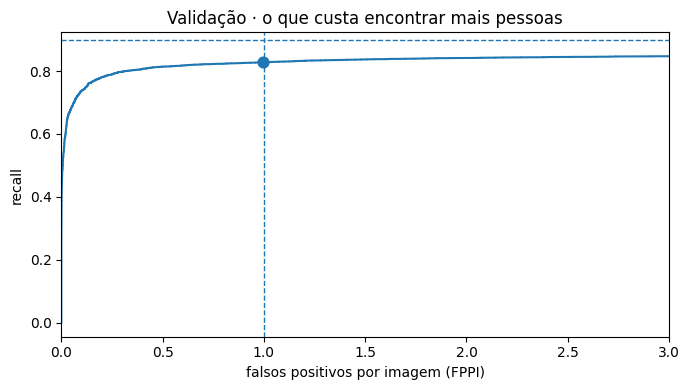

In [9]:
SHA_CHECKPOINT_VALIDADO = sha256(CHECKPOINT)
imagens_val = sorted(catalogo.loc[catalogo.split == "val", "caminho"].tolist())
registros_val = coletar_predicoes(CHECKPOINT, imagens_val)

aval_val = avaliar(registros_val, IOU_MATCH)
ponto = escolher_limiar(aval_val["curva"], RECALL_ALVO, FPPI_MAX)
metricas_val = metricas_no_limiar(registros_val, aval_val, ponto["limiar"])

print("Ponto de operação escolhido na validação:")
print(json.dumps({**ponto, **metricas_val}, indent=2, ensure_ascii=False))
if not ponto["atingiu_alvo"]:
    print(f"\nO alvo de recall {RECALL_ALVO:.0%} com FPPI <= {FPPI_MAX} NÃO foi atingido.")
    print("Este é um resultado legítimo: o modelo não satisfaz o requisito da missão.")

curva = aval_val["curva"]
plt.figure(figsize=(7, 4))
plt.plot(curva.fppi, curva.recall)
plt.scatter([ponto["fppi"]], [ponto["recall"]], s=60, zorder=3)
plt.axhline(RECALL_ALVO, linestyle="--", linewidth=1)
plt.axvline(FPPI_MAX, linestyle="--", linewidth=1)
plt.xlim(0, max(3, FPPI_MAX * 3))
plt.xlabel("falsos positivos por imagem (FPPI)")
plt.ylabel("recall")
plt.title("Validação · o que custa encontrar mais pessoas")
plt.tight_layout()
plt.show()

## 7. Congelar o protocolo

Este é o momento formal do experimento. Gravamos em disco, **antes de tocar no conjunto de
teste**: qual checkpoint será avaliado, seu hash SHA-256, o limiar de confiança escolhido na
validação e todos os parâmetros.

O hash é o que dá substância ao gesto. Sem ele, "congelamos o modelo" é uma afirmação sobre
intenção; com ele, é uma afirmação verificável — qualquer pessoa pode conferir que o arquivo
avaliado no teste é exatamente o mesmo que foi congelado aqui.

A partir desta célula, nada do que você observar no teste pode voltar atrás e alterar uma
decisão anterior. Se, ao ver o resultado, você quiser mudar o limiar, terá criado um
experimento novo — e precisará de um conjunto de teste novo para avaliá-lo honestamente.

In [10]:
MODELO_CONGELADO = EXEC / "modelo_congelado.pt"
ARQ_PROTOCOLO = EXEC / "protocolo_congelado.json"

if sha256(CHECKPOINT) != SHA_CHECKPOINT_VALIDADO:
    raise RuntimeError("O checkpoint mudou desde a calibração. Reexecute a validação.")
if MODELO_CONGELADO.exists():
    if sha256(MODELO_CONGELADO) != SHA_CHECKPOINT_VALIDADO:
        raise RuntimeError("Já existe outro modelo congelado. Use outro NOME_EXECUCAO.")
else:
    shutil.copy2(CHECKPOINT, MODELO_CONGELADO)

conclusao_treino = json.loads(ARQ_CONCLUSAO.read_text(encoding="utf-8"))
if not treino_ja_concluido():
    raise RuntimeError("Conclua e registre o treinamento antes de congelar o protocolo.")

protocolo = {
    "congelado_em": agora(),
    "experimento": NOME_EXECUCAO,
    "checkpoint_origem": str(CHECKPOINT),
    "checkpoint_sha256": sha256(MODELO_CONGELADO),
    "politica_de_checkpoint": POLITICA_CHECKPOINT,
    "especificacao_sha256": sha256(ARQ_ESPECIFICACAO),
    "iou_nms": IOU_NMS, "max_det": MAX_DET, "conf_min": CONF_MIN,
    "confianca_do_artigo": CONF_PAPER,
    "imgsz": IMGSZ,
    "epocas_maximas": EPOCAS,
    "epocas_executadas": conclusao_treino["epocas_executadas"],
    "patience": PACIENCIA,
    "motivo_encerramento": conclusao_treino["motivo"],
    "batch": BATCH,
    "otimizador": OTIMIZADOR,
    "lr0": LR0,
    "ultralytics": ultralytics.__version__,
    "semente": SEMENTE,
    "validacao_conf_artigo": {k: v for k, v in val_paper.items() if k not in ("fps", "ms_por_imagem")},
    "validacao_conf_padrao": {k: v for k, v in val_padrao.items() if k not in ("fps", "ms_por_imagem")},
    "ponto_de_operacao": {
        "escolhido_em": "validação",
        "iou_match": IOU_MATCH,
        "recall_alvo": RECALL_ALVO,
        "fppi_max": FPPI_MAX,
        **ponto,
        "metricas": metricas_val,
    },
}
protocolo = gravar_registro_unico(ARQ_PROTOCOLO, protocolo, ignorar=("congelado_em",))
print(ARQ_PROTOCOLO.read_text(encoding="utf-8"))

{
  "congelado_em": "2026-09-19T13:23:16.692270+00:00",
  "experimento": "yolov8s-pop-seed0-es10",
  "checkpoint_origem": "/workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10/weights/best.pt",
  "checkpoint_sha256": "f92c2d624ee8c6644eb55fae3dbe4c792381e43c5d274cca60938ad6920b0e9c",
  "politica_de_checkpoint": "maior mAP50-95 na validação entre best.pt e last.pt; empate favorece best.pt",
  "especificacao_sha256": "f0b842b7f3b1572210262e06bb375f79bc5bd33d05f129d8507a4d8617139d46",
  "iou_nms": 0.7,
  "max_det": 300,
  "conf_min": 0.001,
  "confianca_do_artigo": 0.5,
  "imgsz": 1280,
  "epocas_maximas": 100,
  "epocas_executadas": 35,
  "patience": 10,
  "motivo_encerramento": "parada_antecipada",
  "batch": 16,
  "otimizador": "SGD",
  "lr0": 0.001,
  "ultralytics": "8.2.0",
  "semente": 0,
  "validacao_conf_artigo": {
    "mAP50": 0.8644518895248285,
    "mAP50-95": 0.674971476097453,
    "precisao": 0.9532311274985446,
    "recall": 0.7503819126183929
  },
  "validacao_c

## 8. A avaliação final, no conjunto de teste

Agora — e só agora — usamos o teste. Uma única vez.

Medimos em três formas complementares:

1. **Como o artigo** (confiança 0,50), para comparar com os valores publicados.
2. **Padrão de AP** (confiança 0,001), a convenção da literatura de detecção.
3. **Missão**, no limiar que congelamos a partir da validação — recall, FPPI e quantas pessoas
   ficaram para trás.

A primeira linha da célula reconfere o hash do modelo. É uma verificação barata contra o erro
mais embaraçoso possível: avaliar um arquivo diferente do que você congelou.

> **Sobre o tempo de inferência reportado.** As colunas `ms_por_imagem` e `fps` medem uma única
> passagem e são sensíveis ao que mais estiver acontecendo na máquina — concorrência por disco,
> por GPU ou por rede, especialmente em servidores compartilhados ou com armazenamento remoto.
> Não é incomum que uma das medições saia dezenas de vezes mais lenta que as demais sem que
> nada tenha mudado no modelo. Ao preparar este material, executamos o notebook duas vezes na
> mesma máquina: em uma delas a medição anômala caiu sobre a primeira linha da tabela, na outra
> sobre a segunda — enquanto os valores de mAP permaneceram idênticos até a quarta casa decimal.
> Se você observar algo assim, desconfie da medição antes de desconfiar da rede neural. Comparar
> velocidade a sério exige repetir a medição em condições controladas, o que está fora do escopo
> deste notebook.

In [11]:
protocolo = json.loads(ARQ_PROTOCOLO.read_text(encoding="utf-8"))
assert sha256(MODELO_CONGELADO) == protocolo["checkpoint_sha256"], \
    "O modelo mudou depois do congelamento — o resultado não seria válido."

assert sha256(ARQ_ESPECIFICACAO) == protocolo["especificacao_sha256"], "A especificação foi alterada."
for chave, atual in {"imgsz": IMGSZ, "batch": BATCH, "iou_nms": IOU_NMS,
                     "max_det": MAX_DET, "conf_min": CONF_MIN}.items():
    if atual != protocolo[chave]:
        raise RuntimeError(f"{chave} diverge do protocolo; restaure a configuração congelada.")
limiar_congelado = protocolo["ponto_de_operacao"]["limiar"]
iou_congelado = protocolo["ponto_de_operacao"]["iou_match"]

teste_paper = metricas_ultralytics(MODELO_CONGELADO, "test", conf=protocolo["confianca_do_artigo"])
teste_padrao = metricas_ultralytics(MODELO_CONGELADO, "test", conf=protocolo["conf_min"])

imagens_teste = sorted(catalogo.loc[catalogo.split == "test", "caminho"].tolist())
registros_teste = coletar_predicoes(MODELO_CONGELADO, imagens_teste)
aval_teste = avaliar(registros_teste, iou_congelado)
teste_missao = metricas_no_limiar(registros_teste, aval_teste, limiar_congelado)

resultado = {
    "avaliado_em": agora(),
    "protocolo_sha256": sha256(ARQ_PROTOCOLO),
    "como_no_artigo": teste_paper,
    "padrao_de_ap": teste_padrao,
    "missao": {"limiar_vindo_da_validacao": limiar_congelado, **teste_missao},
}
(EXEC / "resultado_teste.json").write_text(json.dumps(resultado, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(resultado, indent=2, ensure_ascii=False))

Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/test... 900 images, 0 backgrounds, 0 corrupt: 100%|██████████| 900/900 [00:01<00:00, 498.44it/s]


val: New cache created: /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/test.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:06<00:00,  9.31it/s]

                   all        900       1840      0.925      0.524      0.736       0.43
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 0.4ms postprocess per image


Ultralytics YOLOv8.2.0 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /workspace/projeto-pop-es10-20260919/data/pop_yolo/labels/test.cache... 900 images, 0 backgrounds, 0 corrupt: 100%|██████████| 900/900 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:06<00:00,  9.18it/s]

                   all        900       1840       0.82      0.601      0.721      0.387
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 0.5ms postprocess per image


{
  "avaliado_em": "2026-09-19T13:24:51.192509+00:00",
  "protocolo_sha256": "1b2e4230e1978e2dd14486e21e5b7bdc4ace3d9ad172c26eb1e501ef814e08bd",
  "como_no_artigo": {
    "mAP50": 0.7358895145712674,
    "mAP50-95": 0.43002542701058905,
    "precisao": 0.9251439539347409,
    "recall": 0.5239130434782608,
    "ms_por_imagem": 4.036194218529595,
    "fps": 247.75814687240316
  },
  "padrao_de_ap": {
    "mAP50": 0.7207950511977788,
    "mAP50-95": 0.3868525148024782,
    "precisao": 0.8203695074049695,
    "recall": 0.6005434782608695,
    "ms_por_imagem": 3.9959404203626847,
    "fps": 250.25398149185534
  },
  "missao": {
    "limiar_vindo_da_validacao": 0.06858426332473755,
    "confianca": 0.06858426332473755,
    "recall": 0.7048913043478261,
    "precisao": 0.46058238636363635,
    "fppi": 1.6877777777777778,
    "pessoas_nao_encontradas": 543
  }
}


### 8.1 O ponto de operação se mantém no teste?

Compare o bloco `missao` com a validação, verificando **os dois requisitos**: recall ≥ 0,90 e
FPPI ≤ 1,0. Registre se foram atingidos em cada conjunto. Na execução de referência da preparação
deste material, o teste teve recall menor e FPPI maior; sua conclusão deve vir dos seus números.

O limiar calibrado em uma cena pode falhar em outra. Se isso acontecer, registre a falha sem
recalibrar olhando o teste. Uma nova decisão exige outra avaliação independente.

### 8.2 Comparação com os valores publicados

Song et al. reportam, para a YOLOv8s no POP: mAP50 de 0,87, mAP50-95 de 0,62, precisão de 0,93
e recall de 0,78.

Ao comparar, tenha em mente duas coisas.

Antes, um alerta sobre o que estas colunas medem. A precisão e o recall desta tabela são os do
ponto de **melhor F1** da curva, que é como a Ultralytics os reporta — não são os do limiar de
0,50 nem os do ponto de operação da missão. É por isso que o recall aqui difere do recall da
seção 6: os dois números estão certos e medem coisas diferentes. Para comparar com o artigo,
adotamos a convenção da biblioteca; o artigo não detalha o suficiente para garantir equivalência.

Primeiro, **uma diferença não significa que alguém errou**. Semente, versão da biblioteca,
política de escolha de checkpoint e detalhes de augmentation não reportados são fontes legítimas
de variação. Reproduzir é mapear essas diferenças, não acusar.

Segundo, **compare também com os seus números de validação**, impressos na seção 5.1. Se os valores
publicados estiverem mais próximos da sua validação do que do seu teste, isso é uma observação
interessante — e vale perguntar o que explicaria o padrão, em vez de assumir uma resposta.

In [12]:
referencia = {"mAP50": 0.87, "mAP50-95": 0.62, "precisao": 0.93, "recall": 0.78}

comparacao = pd.DataFrame({
    "Song et al. (2025)": referencia,
    "seu teste": {k: teste_paper.get(k, np.nan) for k in referencia},
    "sua validação": {k: val_paper.get(k, np.nan) for k in referencia},
})
comparacao["teste − artigo"] = comparacao["seu teste"] - comparacao["Song et al. (2025)"]
display(comparacao.round(4))

,Song et al. (2025),seu teste,sua validação,teste − artigo
mAP50,0.87,0.7359,0.8645,-0.1341
mAP50-95,0.62,0.4300,0.6750,-0.1900
precisao,0.93,0.9251,0.9532,-0.0049
recall,0.78,0.5239,0.7504,-0.2561


## 9. Onde o modelo erra

Um número agregado esconde a estrutura do erro. Um recall de 70% pode significar que o modelo
falha uniformemente em 30% dos casos — ou que acerta quase tudo, exceto numa condição específica
onde falha quase sempre. As duas situações pedem respostas de engenharia opostas.

As três tabelas abaixo quebram o resultado por cena, por altitude de voo e por tamanho aparente
da pessoa. Ao lê-las, pergunte-se:

- **Alguma cena destoa?** Isso apontaria para um tipo de terreno ou vegetação mal representado
  no treino.
- **O recall cai com a altitude?** Seria esperado: mais alto significa alvos menores. Mas
  resista à conclusão fácil de que "basta voar mais baixo". Antes, olhe o tamanho de cada
  estrato e cruze com a tabela por cena. Altitude, cena, vegetação e número de pessoas por
  quadro variam **juntos** neste dataset, e as três cenas de teste têm desempenhos muito
  diferentes entre si. O que a tabela por altitude mostra não é o efeito isolado da altitude —
  é o efeito de tudo aquilo que varia junto com ela.
- **E com o tamanho?** Compare com a distribuição da seção 6 do **notebook 01**. A faixa onde o
  modelo mais erra é também a mais frequente no dataset?

In [13]:
def tabela_por_grupo(registros, aval, limiar, chave, nome):
    linhas = []
    for r, (_, gt_conf) in zip(registros, aval["casamentos"]):
        tp = int((gt_conf >= limiar).sum())
        n_pred = int((r["pred_conf"] >= limiar).sum())
        linhas.append({nome: chave(r), "tp": tp, "fp": n_pred - tp, "gt": len(r["gt_xyxy"])})
    df = pd.DataFrame(linhas)
    t = df.groupby(nome).agg(imagens=("gt", "size"), pessoas=("gt", "sum"),
                             encontradas=("tp", "sum"), falsos_positivos=("fp", "sum"))
    t["recall"] = t.encontradas / t.pessoas.clip(lower=1)
    t["fppi"] = t.falsos_positivos / t.imagens
    return t


def recall_por_tamanho(registros, aval, limiar, faixas=((0, 20), (20, 40), (40, float("inf")))):
    lados, confs = [], []
    for r, (_, gc) in zip(registros, aval["casamentos"]):
        g = r["gt_xyxy"]
        lados.extend(np.minimum(g[:, 2] - g[:, 0], g[:, 3] - g[:, 1]).tolist())
        confs.extend(gc.tolist())
    lados, confs = np.asarray(lados), np.asarray(confs)
    saida = []
    for lo, hi in faixas:
        m = (lados >= lo) & (lados < hi)
        saida.append({
            "faixa_px": f"{lo}–{hi}" if np.isfinite(hi) else f">={lo}",
            "pessoas": int(m.sum()),
            "recall": float((confs[m] >= limiar).mean()) if m.any() else np.nan,
        })
    return pd.DataFrame(saida)


lim = protocolo["ponto_de_operacao"]["limiar"]
print("Desempenho por cena")
display(tabela_por_grupo(registros_teste, aval_teste, lim, lambda r: r["cena"], "cena").round(4))
print("\nDesempenho por altitude de voo (metros)")
display(tabela_por_grupo(registros_teste, aval_teste, lim, lambda r: r["faixa"], "altitude").round(4))
print("\nDesempenho por tamanho aparente da pessoa")
display(recall_por_tamanho(registros_teste, aval_teste, lim).round(4))

Desempenho por cena


,imagens,pessoas,encontradas,falsos_positivos,recall,fppi
cena,,,,,,
T1,306,501,405,527,0.8084,1.7222
T2,258,686,255,507,0.3717,1.9651
T3,336,653,637,485,0.9755,1.4435



Desempenho por altitude de voo (metros)


,imagens,pessoas,encontradas,falsos_positivos,recall,fppi
altitude,,,,,,
30,102,102,102,145,1.0000,1.4216
50,731,1604,1131,1226,0.7051,1.6772
70,67,134,64,148,0.4776,2.2090



Desempenho por tamanho aparente da pessoa


,faixa_px,pessoas,recall
0,0–20,110,0.4545
1,20–40,1328,0.6687
2,>=40,402,0.8930


## 10. O que este experimento não resolve

Encerrar listando as limitações não é modéstia — é o que separa um resultado utilizável de um
número solto. Se você for usar este notebook como base de um trabalho, comece por aqui.

**Sobre a reprodução**

A versão didática usa parada antecipada (`patience=10`) e limite de 100 épocas. O artigo
reporta 100 épocas e nossa execução de referência também cumpriu esse orçamento completo.
Informe as épocas efetivamente executadas ao apresentar os resultados; a adaptação pode
encerrar antes da fase sem mosaico e não garante equivalência com o treinamento completo.

1. O artigo não informa a semente, a política de escolha de checkpoint nem as probabilidades de
   augmentation. Parte do que determina o seu resultado foi herdada dos defaults da Ultralytics.
2. O artigo informa imagens de 1280×1024 com mosaico ativo. O pipeline padrão da Ultralytics
   trabalha com `imgsz` escalar; a geometria exata do treinamento dos autores não é reproduzível
   apenas a partir do texto.
3. Há uma discrepância nas anotações: o texto cita 25.811 caixas, enquanto a Tabela 4 e os
   arquivos distribuídos somam 26.811.

**Sobre a medição**

4. O FPPI é informativo, mas limitado neste dataset: o POP não tem **nenhuma** imagem sem
   pessoas, como você verificou no notebook 01. Em uma operação real, a maior parte do tempo de voo é sobre terreno vazio — e é lá
   que os alarmes falsos realmente pesam. Medir FPPI apenas em imagens que contêm pessoas
   não permite estimar a taxa de alarmes em terreno vazio.
5. A comparação de FPS depende de hardware, tamanho de lote e do que se considera "tempo de
   inferência". O valor medido aqui exclui pré e pós-processamento.

**Sobre o problema**

6. **Altitude, cena e tamanho variam juntos.** A tabela por altitude da seção 9 não mede o efeito
   isolado da altitude. Como mostra o notebook 00, várias cenas contêm as três faixas, mas
   T2 e T3 só contêm a faixa de 50 m. A composição de cenas e alvos muda entre faixas.
   A comparação dentro de cena reduz parte dessa confusão; isolar o efeito ainda exige
   controlar posição, postura, oclusão e condições de captura dos mesmos alvos.

7. A oclusão não é uma variável anotada no POP. Não conseguimos, com estes dados, separar o erro
   causado por oclusão do erro causado por tamanho reduzido — embora o artigo trate a oclusão
   como característica central do dataset. Responder a isso exigiria anotação adicional.

**Caminhos naturais a partir daqui**

- Detectar em recortes da imagem em vez da imagem inteira, para dar mais pixels a cada alvo.
- Acrescentar imagens sem pessoas ao treino e medir o efeito no FPPI.
- Agregar detecções ao longo de quadros consecutivos: uma pessoa parcialmente oculta em um
  quadro pode estar visível no seguinte.
- Tratar a oclusão como variável anotada, o que permitiria medir diretamente o que hoje só
  conseguimos inferir.